# GPU programming is cost-model first

A 1-hour course for database & systems researchers. One thesis, proven by measurement on the hardware in front of us:

> **You don't pick an algorithm and then make the chip run it. You compute the cost model first -- bytes moved, passes over memory, latency vs concurrency, where the data lives, how you access it -- and *that* selects the algorithm before you write a line.** Asymptotic optimality is not hardware-neutral; "best" is a function of the chip.

**The chip:** a single **RTX 6000 Ada** (sm_89, AD102) -- 48 GB **GDDR6** ~960 GB/s, **96 MB L2**, register file ~36 MB. It is two things at once: a **bandwidth machine** (huge throughput, but only if you keep it fed) and a **latency-hiding concurrency machine** (per-access latency is *bad*; throughput comes from running thousands of warps so a stall in one is covered by another). GPU programming is therefore not only **parallel** -- it's **concurrent**: latency forces you to always have other work in flight.

**The spine:** two sorts tell the rest of the story from two angles -- **radix** = *massive parallelism collapses the algorithm; linear-time wins*, **merge** = *the cache / access-pattern / memory-hierarchy story* -- and a production library is just a **frozen cost-model decision tree** that picks between them for you.

## Time budget -- 1 hour (~51 min content + ~5 Q&A)

| # | section | min |
|---|---|---|
| 0 | Thesis + hardware | 3 |
| 1 | Bandwidth identity | 4 |
| 2 | **Latency & how the GPU hides it** (concurrency) | 6 |
| 3 | Cache cliff (measure at GB) | 4 |
| 4 | **Cost model in two lines** (thrust dispatch) | 5 |
| 5 | Two sorts (framing) | 2 |
| 5a | Radix: passes-law + 4x merge | 9 |
| 5b | Merge: hierarchy + ablation | 9 |
| 6 | Kernel is ~10% (rug pull) | 6 |
| 7 | Closing | 3 |
| - | Q&A | 5 |

(SASS-diff and histogram sections were cut for time; they live in the repo as
supporting material.)

In [1]:
%matplotlib inline
import subprocess, re, os
import matplotlib.pyplot as plt

ROOT = os.getcwd()
GPU, CPU, RADIX, MERGE, INK, CEIL = "#76b900", "#5b6770", "#0b84a5", "#c0392b", "#23272b", "#b9bfc4"
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#eef1f3", "axes.axisbelow": True})

def sh(cmd, cwd=None, timeout=900):
    r = subprocess.run(cmd, shell=True, cwd=cwd or ROOT, capture_output=True, text=True, timeout=timeout)
    return r.stdout + r.stderr

def grab(text, pat):
    m = re.search(pat, text); return float(m.group(1)) if m else float("nan")

sh("make -s -C demo1_bandwidth; make -s -C demo2_sort; make -s -C demo3_rugpull")
sh("cd demo6_mergesort && nvcc -O3 -std=c++17 -arch=sm_89 -o cub_compare cub_compare.cu && "
   "nvcc -O3 -std=c++17 -arch=sm_89 -o thrust_compare thrust_compare.cu")
sh("cd demo7_latency && nvcc -O3 -std=c++17 -arch=sm_89 -o latency latency.cu")
print("built.")

built.


## 1. The chip's identity is bandwidth  (~4 min)

A trivial streaming copy. The CPU's STREAM Triad tops out well below its (small) DRAM peak; the GPU's copy kernel saturates its (much larger) bus. The story is the *ratio*, and that the GPU number comes from a kernel you could write in your sleep.

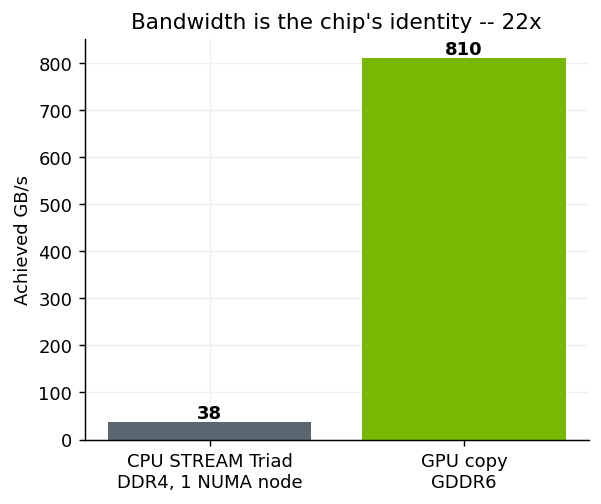

In [2]:
g = grab(sh("./stream_gpu", cwd=f"{ROOT}/demo1_bandwidth"), r"copy kernel:\s*([\d.]+)")
numa = "numactl --cpunodebind=0 --membind=0 " if sh("which numactl").strip() else ""
c = grab(sh(f"OMP_NUM_THREADS=6 OMP_PROC_BIND=close OMP_PLACES=cores {numa}./stream_cpu",
            cwd=f"{ROOT}/demo1_bandwidth"), r"triad bandwidth:\s*([\d.]+)")
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["CPU STREAM Triad\nDDR4, 1 NUMA node", "GPU copy\nGDDR6"], [c, g], color=[CPU, GPU])
ax.set_ylabel("Achieved GB/s"); ax.set_title(f"Bandwidth is the chip's identity -- {g/c:.0f}x")
for i, v in enumerate([c, g]): ax.text(i, v, f"{v:.0f}", ha="center", va="bottom", fontweight="bold")
plt.show()

## 2. The hidden half: latency, and how the GPU hides it  (~6 min)

That bandwidth is **not free** -- it's *hidden latency*. The GPU's per-access latency is **bad**: a single thread chasing dependent loads to HBM waits hundreds of ns / hundreds of cycles per access -- worse than a CPU cache. **One GPU thread is slow.**

The trick is **concurrency**: oversubscribe with thousands of warps; when one stalls on a load, the scheduler switches to a ready one in *zero cycles* (every warp's state lives in the register file). Bandwidth is simply what you get once enough warps are in flight to cover every stall. Watch the *same copy kernel* climb from a few % to ~85% of peak as we add warps -- that curve is the GPU's whole personality.

**Little's law:** bandwidth = bytes-in-flight / latency. To fill ~960 GB/s at ~230 ns you need ~220 KB in flight -> thousands of concurrent loads -> thousands of warps. *That* is why the chip has a ~36 MB register file and lightweight threads. Not just parallel -- **concurrent**.

=== Part A: raw memory latency (1 thread, dependent loads) ===
  HBM access latency: 229 ns  (~574 cycles @ 2.50 GHz)

=== Part B: copy bandwidth vs resident warps (latency hiding) ===
  warps     GB/s   % of peak
       8     30.4     3.2%
      16     58.7     6.1%
      32    113.0    11.8%
      64    216.0    22.5%
     128    397.3    41.4%
     256    673.3    70.1%
     512    828.0    86.3%
    1024    805.5    83.9%
    2048    807.1    84.1%
    8192    791.4    82.4%
   36352    802.8    83.6%

  Little's law: to fill ~960 GB/s at 229 ns latency you need ~220 KB
  in flight -> thousands of concurrent loads -> thousands of warps.
  That is why the GPU has a ~36 MB register file and lightweight threads.



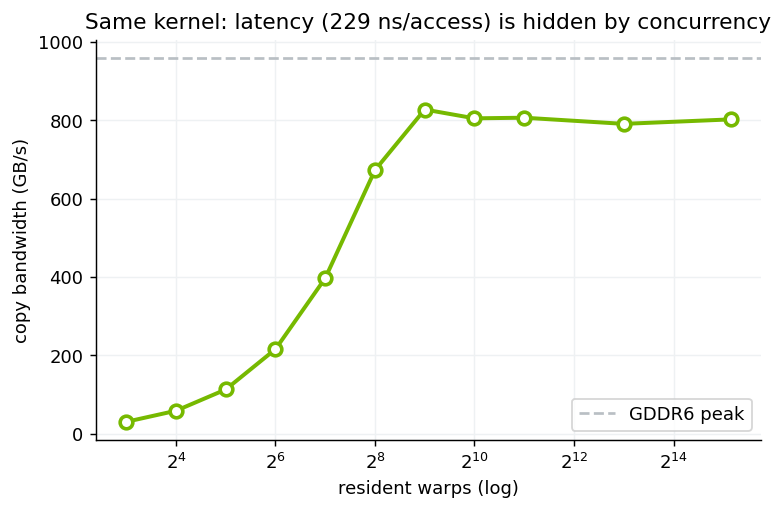

In [3]:
out = sh("./latency", cwd=f"{ROOT}/demo7_latency"); print(out)
lat = grab(out, r"latency:\s*([\d.]+)\s*ns")
rows = re.findall(r"^\s*(\d+)\s+([\d.]+)\s+[\d.]+%\s*$", out, re.M)
warps = [int(a) for a, _ in rows]; gbps = [float(b) for _, b in rows]
fig, ax = plt.subplots(figsize=(6.6, 4))
ax.plot(warps, gbps, "o-", color=GPU, lw=2.2, ms=7, mfc="white", mew=2)
ax.axhline(960, ls="--", color=CEIL, label="GDDR6 peak")
ax.set_xscale("log", base=2); ax.set_xlabel("resident warps (log)"); ax.set_ylabel("copy bandwidth (GB/s)")
ax.set_title(f"Same kernel: latency ({lat:.0f} ns/access) is hidden by concurrency")
ax.legend(loc="lower right")
plt.show()

## 3. ...and the cache hides it too -- so measure at GB scale  (~4 min)

Run the *same naive sort kernel* across sizes. Below 96 MB the array lives in L2 and throughput is ~4x higher than reality; cross the L2 and you fall off a cliff to true HBM-bound speed. **Any benchmark that fits in cache is lying to you** -- everything past here runs at >= 1 GB.

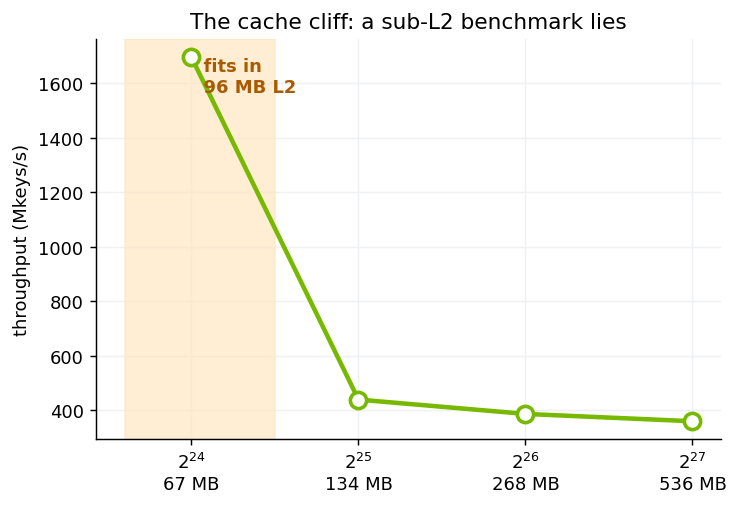

In [4]:
sizes = [24, 25, 26, 27]
mk = [grab(sh(f"./v0_naive {s} 5", cwd=f"{ROOT}/demo2_sort"), r"([\d.]+)\s*Mkeys/s") for s in sizes]
fig, ax = plt.subplots(figsize=(6.2, 4)); x = range(len(sizes))
ax.plot(x, mk, "o-", color=GPU, lw=2.5, ms=9, mfc="white", mew=2)
ax.axvspan(-0.4, 0.5, color="#ffe7c2", alpha=0.7)
ax.text(0, mk[0], "  fits in\n  96 MB L2", va="top", color="#a85b00", fontweight="bold")
ax.set_xticks(list(x)); ax.set_xticklabels([f"$2^{{{s}}}$\n{2**s*4//10**6} MB" for s in sizes])
ax.set_ylabel("throughput (Mkeys/s)"); ax.set_title("The cache cliff: a sub-L2 benchmark lies")
plt.show()

## 4. The cost model, in two lines of user code  (~5 min, the hook)

The highest-level GPU sort API -- `thrust::sort` -- *already* embodies the thesis. Its dispatch (`thrust/system/cuda/detail/sort.h`, `can_use_primitive_sort`) picks at **compile time**:

```cpp
// arithmetic key (int/float...) AND default less/greater  -> RADIX  (cub::DeviceRadixSort)
// custom comparator, or non-arithmetic key                -> MERGE  (cub::DeviceMergeSort)
```

These two calls sort the *same data into the same order* -- the only difference is a comparator whose type happens to mean `a < b` -- yet one is several times slower, because its type blocks the radix path. **The cost model, triggered by a type, invisible to the user.**

n=2^28 (268M keys)
  thrust::sort(x)           -> radix :   18.870 ms  [PASS]
  thrust::sort(x, MyLess()) -> merge :   54.603 ms  [PASS]
  one custom comparator cost you 2.9x -- the cost model, by type.



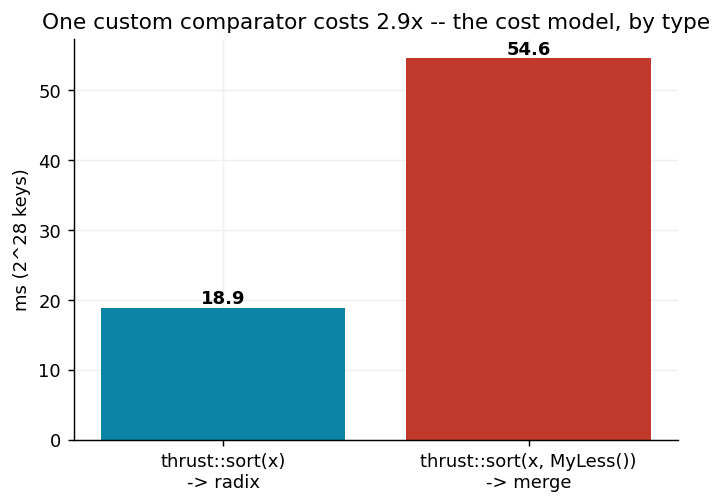

In [5]:
out = sh("./thrust_compare 28 6", cwd=f"{ROOT}/demo6_mergesort"); print(out)
r = grab(out, r"-> radix :\s*([\d.]+)"); m = grab(out, r"-> merge :\s*([\d.]+)")
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["thrust::sort(x)\n-> radix", "thrust::sort(x, MyLess())\n-> merge"], [r, m], color=[RADIX, MERGE])
ax.set_ylabel("ms (2^28 keys)"); ax.set_title(f"One custom comparator costs {m/r:.1f}x -- the cost model, by type")
for i, v in enumerate([r, m]): ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontweight="bold")
plt.show()

## 5. Two sorts, two truths about the chip  (framing ~2 min)

Why ship *both*? Because there's no single best sort -- the cost model picks the game. The two algorithms illuminate the two halves of "what is a GPU."

### 5a. Radix -- *massive parallelism collapses the algorithm; linear time wins*  (~9 min)

On a CPU you're taught O(n log n) comparison sort is optimal and you ignore radix for its constants. The GPU inverts the cost model: with near-perfect data-parallelism the per-element work is free, so **only passes over memory count** -- and O(n)-pass radix beats O(n log n) merge. The naive-to-radix arc (bitonic is just the bad global-memory baseline that motivates it), then radix vs a *fully optimized* CUB merge at GB scale.

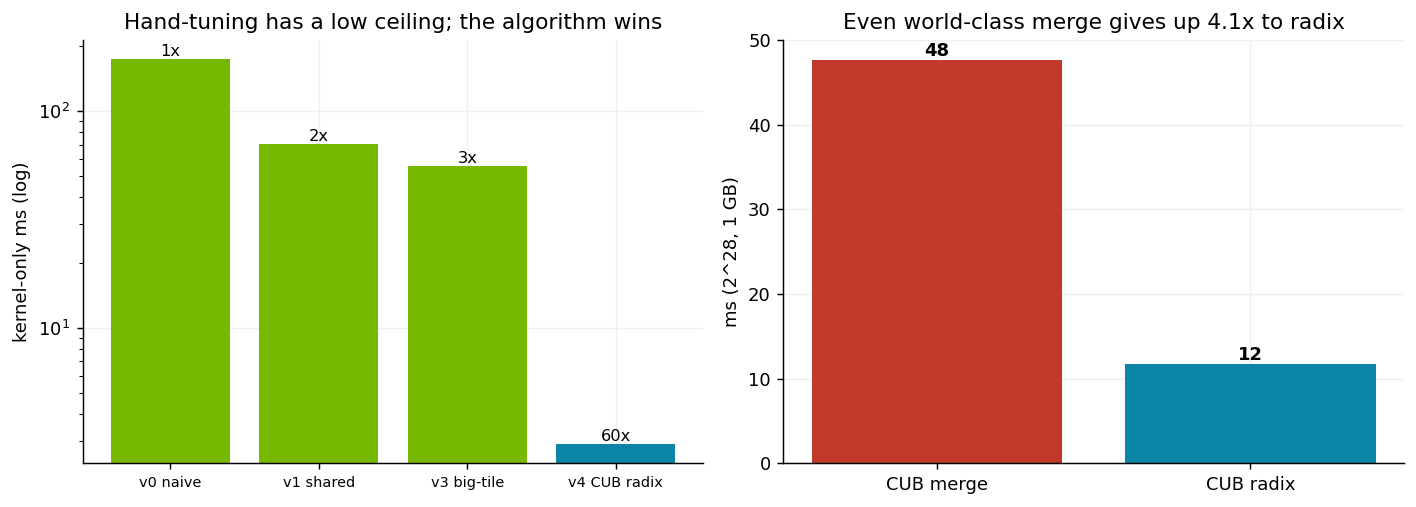

In [6]:
ARC = [("v0_naive","v0 naive"),("v1_shared","v1 shared"),("v3_multiblock","v3 big-tile"),("v4_cub","v4 CUB radix")]
ms = {lbl: grab(sh(f"./{b} 26 10", cwd=f"{ROOT}/demo2_sort"), r"([\d.]+)\s*ms") for b, lbl in ARC}
base = ms["v0 naive"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
bars = a1.bar(list(ms), list(ms.values()), color=[GPU, GPU, GPU, RADIX]); a1.set_yscale("log")
a1.set_ylabel("kernel-only ms (log)"); a1.set_title("Hand-tuning has a low ceiling; the algorithm wins")
for b, v in zip(bars, ms.values()): a1.text(b.get_x()+b.get_width()/2, v, f"{base/v:.0f}x", ha="center", va="bottom", fontsize=9)
a1.tick_params(axis="x", labelsize=8)
out = sh("./cub_compare 28 6", cwd=f"{ROOT}/demo6_mergesort")
cm = grab(out, r"merge sort :\s*([\d.]+)"); cr = grab(out, r"radix sort :\s*([\d.]+)")
a2.bar(["CUB merge", "CUB radix"], [cm, cr], color=[MERGE, RADIX]); a2.set_ylabel("ms (2^28, 1 GB)")
a2.set_title(f"Even world-class merge gives up {cm/cr:.1f}x to radix")
for i, v in enumerate([cm, cr]): a2.text(i, v, f"{v:.0f}", ha="center", va="bottom", fontweight="bold")
plt.tight_layout(); plt.show()

### 5b. Merge -- *the cache / access-pattern / memory-hierarchy story*  (~9 min)

Merge is the **general** sort (any comparator, where radix can't go), and its CUB implementation is pure hierarchy choreography -- you don't change the algorithm, you change *where data lives and how you touch it*: per-thread **register sorting-networks**, **shared-memory merge tiles** with **`MergePath` co-rank**, and a device-level merge of tiles.

Does *gradually tuning* those layers actually climb on this hardware, or has the big L2 + fast shared atomics flattened the middle? We ablate -- start from CUB-faithful code, remove one optimization at a time at GB scale. Register blocking (`ITEMS_PER_THREAD`) is the first knob:

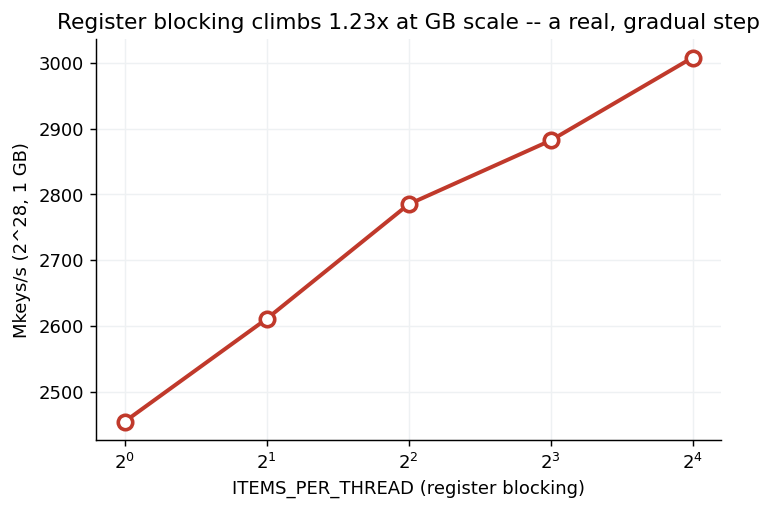

The merge-tuning arc is NOT flat: structural/data-layout opts hold on modern HW.


In [7]:
# register-blocking ablation: rebuild merge sort with IPT 1..16 and sort 1 GB
res = {}
for ipt in [1, 2, 4, 8, 16]:
    sh(f"cd demo6_mergesort && nvcc -O3 -std=c++17 -arch=sm_89 -DIPT={ipt} -o /tmp/m{ipt} merge_ablation.cu")
    res[ipt] = grab(sh(f"/tmp/m{ipt} 28 6", cwd=f"{ROOT}/demo6_mergesort"), r"([\d.]+)\s*Mkeys/s")
fig, ax = plt.subplots(figsize=(6.2, 4))
ax.plot(list(res), list(res.values()), "o-", color=MERGE, lw=2.2, ms=8, mfc="white", mew=2)
ax.set_xscale("log", base=2); ax.set_xlabel("ITEMS_PER_THREAD (register blocking)")
ax.set_ylabel("Mkeys/s (2^28, 1 GB)")
lo, hi = res[1], res[16]
ax.set_title(f"Register blocking climbs {hi/lo:.2f}x at GB scale -- a real, gradual step")
plt.show()
print("The merge-tuning arc is NOT flat: structural/data-layout opts hold on modern HW.")

## 6. The kernel is ~10%  (~6 min)

Take the best hand-rolled sort and wrap it the way a query stage actually runs: allocate, copy in, sort, copy out, free -- every iteration. The kernel never changes, yet per-iteration time swings wildly. `cudaMalloc`/`cudaFree` are synchronous driver calls; a stream-ordered pool (`cudaMallocAsync`) and a CUDA graph claw the time back -- none of it by touching the kernel.

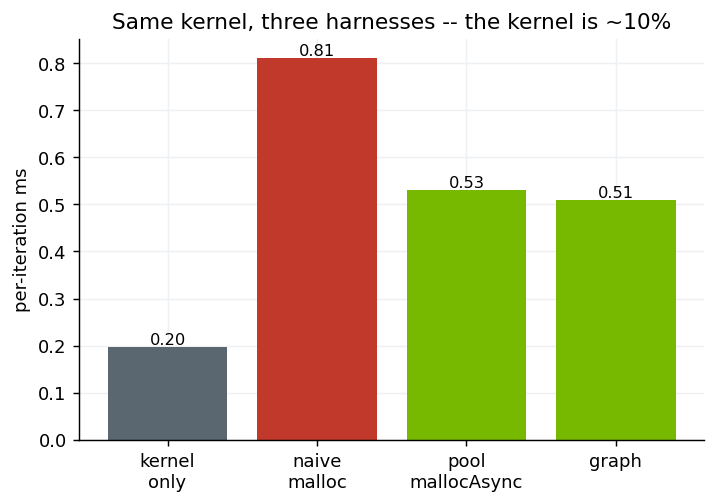

In [8]:
H = ["naive", "pool", "graph"]
outs = {h: sh(f"./{h}_harness 20 200", cwd=f"{ROOT}/demo3_rugpull") for h in H}
pit = {h: grab(outs[h], r"per-iter\s*:\s*([\d.]+)") for h in H}
kon = grab(outs["naive"], r"kernel-only\s*:\s*([\d.]+)")
fig, ax = plt.subplots(figsize=(6.2, 4))
ax.bar(["kernel\nonly", "naive\nmalloc", "pool\nmallocAsync", "graph"], [kon, pit["naive"], pit["pool"], pit["graph"]],
       color=[CPU, MERGE, GPU, GPU])
ax.set_ylabel("per-iteration ms"); ax.set_title("Same kernel, three harnesses -- the kernel is ~10%")
for i, v in enumerate([kon, pit["naive"], pit["pool"], pit["graph"]]): ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
plt.show()

## Closing: the library is a frozen cost-model decision tree  (~3 min)

Everything pointed one way. The chip is a **bandwidth machine you keep fed by hiding latency with concurrency**; on top of that, `thrust::sort` picks radix-vs-merge by *type* at compile time, and CUB ships *both* sorts (and both an atomic and a sort-based histogram). The experts didn't find *the* answer -- they encoded the **question** and a chooser, because the right choice is a function of the input and the chip.

So the one sentence to leave with: **compute the cost model first.** Bytes moved, passes, latency vs concurrency, where the data lives, how you access it -- that arithmetic selects the algorithm, tells you when to stop tuning, and tells you which library call to make. On a GPU, that is the program; the kernel is a detail.